In [2]:
import pandas as pd

In [12]:
data = pd.read_csv("realtor-data.csv")

In [13]:
print(data.head())

   brokered_by    status     price  bed  bath  acre_lot     street  \
0     103378.0  for_sale  105000.0  3.0   2.0      0.12  1962661.0   
1      52707.0  for_sale   80000.0  4.0   2.0      0.08  1902874.0   
2     103379.0  for_sale   67000.0  2.0   1.0      0.15  1404990.0   
3      31239.0  for_sale  145000.0  4.0   2.0      0.10  1947675.0   
4      34632.0  for_sale   65000.0  6.0   2.0      0.05   331151.0   

         city        state  zip_code  house_size prev_sold_date  
0    Adjuntas  Puerto Rico     601.0       920.0            NaN  
1    Adjuntas  Puerto Rico     601.0      1527.0            NaN  
2  Juana Diaz  Puerto Rico     795.0       748.0            NaN  
3       Ponce  Puerto Rico     731.0      1800.0            NaN  
4    Mayaguez  Puerto Rico     680.0         NaN            NaN  


In [16]:
data.drop(columns = ["brokered_by","zip_code","prev_sold_date"],inplace = True)

In [17]:
data

,status,price,bed,bath,acre_lot,street,city,state,house_size
0,for_sale,105000.0,3.0,2.0,0.12,1962661.0,Adjuntas,Puerto Rico,920.0
1,for_sale,80000.0,4.0,2.0,0.08,1902874.0,Adjuntas,Puerto Rico,1527.0
2,for_sale,67000.0,2.0,1.0,0.15,1404990.0,Juana Diaz,Puerto Rico,748.0
3,for_sale,145000.0,4.0,2.0,0.10,1947675.0,Ponce,Puerto Rico,1800.0
4,for_sale,65000.0,6.0,2.0,0.05,331151.0,Mayaguez,Puerto Rico,NaN
...,...,...,...,...,...,...,...,...,...
2226377,sold,359900.0,4.0,2.0,0.33,353094.0,Richland,Washington,3600.0
2226378,sold,350000.0,3.0,2.0,0.10,1062149.0,Richland,Washington,1616.0
2226379,sold,440000.0,6.0,3.0,0.50,405677.0,Richland,Washington,3200.0
2226380,sold,179900.0,2.0,1.0,0.09,761379.0,Richland,Washington,933.0


In [20]:
data.isna().sum().sum()
data.dropna(inplace = True)

In [22]:
data.isna().sum()

status        0
price         0
bed           0
bath          0
acre_lot      0
street        0
city          0
state         0
house_size    0
dtype: int64

In [24]:
data.duplicated().sum()

np.int64(535)

In [25]:
data.drop_duplicates(inplace = True)

In [27]:
data.duplicated().sum()

np.int64(0)

In [32]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'Number of Houses')

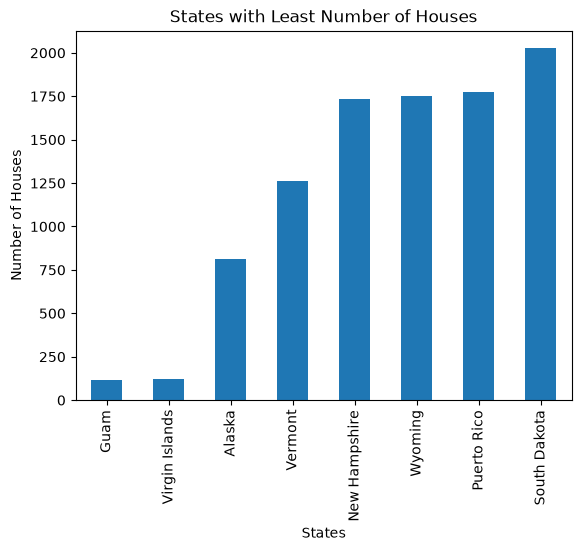

In [34]:
data["state"].value_counts().sort_values(ascending = True).head(8).plot(kind = "bar")
plt.title("States with Least Number of Houses")
plt.xlabel("States")
plt.ylabel("Number of Houses")

In [41]:
data.groupby(["state","city"])["price"].mean().reset_index()

,state,city,price
0,Alabama,Abbeville,2.201540e+05
1,Alabama,Adamsville,1.384411e+05
2,Alabama,Addison,1.459500e+05
3,Alabama,Adger,1.743727e+05
4,Alabama,Akron,4.389400e+05
...,...,...,...
26255,Wyoming,Wheatland,2.815783e+05
26256,Wyoming,Wilson,5.719900e+06
26257,Wyoming,Worland,2.889077e+05
26258,Wyoming,Wright,2.911600e+05


In [43]:
data.select_dtypes(include = "number")

,price,bed,bath,acre_lot,street,house_size
0,105000.0,3.0,2.0,0.12,1962661.0,920.0
1,80000.0,4.0,2.0,0.08,1902874.0,1527.0
2,67000.0,2.0,1.0,0.15,1404990.0,748.0
3,145000.0,4.0,2.0,0.10,1947675.0,1800.0
5,179000.0,4.0,3.0,0.46,1850806.0,2520.0
...,...,...,...,...,...,...
2226377,359900.0,4.0,2.0,0.33,353094.0,3600.0
2226378,350000.0,3.0,2.0,0.10,1062149.0,1616.0
2226379,440000.0,6.0,3.0,0.50,405677.0,3200.0
2226380,179900.0,2.0,1.0,0.09,761379.0,933.0


In [42]:
data.select_dtypes(include = "number").corr()["price"]

price         1.000000
bed           0.117585
bath          0.208868
acre_lot      0.005304
street        0.000481
house_size    0.073849
Name: price, dtype: float64

In [49]:
X = data[["bed","bath","house_size"]]
Y = data["price"]

In [52]:
from sklearn.model_selection import train_test_split

In [53]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size = 0.2)

In [54]:
from sklearn.preprocessing import StandardScaler

In [55]:
Scalar = StandardScaler()

In [56]:
X_train = Scalar.fit_transform(X_train)

In [57]:
X_train

array([[ 0.43999601,  0.33745761, -0.01346357],
       [ 1.8727045 ,  2.54578302,  0.15765691],
       [-0.27635823, -0.39865086, -0.11062324],
       ...,
       [-0.27635823, -0.39865086, -0.11521708],
       [-0.27635823, -1.13475932, -0.22317228],
       [ 0.43999601,  0.33745761,  0.02788098]], shape=(1084689, 3))

In [59]:
import joblib
joblib.dump(Scalar,"Scalar.pkl")

['Scalar.pkl']

In [60]:
X_test = Scalar.transform(X_test)

In [63]:
from sklearn.linear_model import LinearRegression

In [64]:
lr = LinearRegression()

In [66]:
lr.fit(X_train,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[-110558.99, 527489.3 , 63274.64]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5.742e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](3,)","[1392.76, 992.05, 574.57]"


In [67]:
predictions = lr.predict(X_test)

In [68]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(Y_test,predictions)

352496.36838974076

In [69]:
joblib.dump(lr,"model.pkl")

['model.pkl']